## Bibliotecas

In [1]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForCausalLM
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
from sentence_transformers import SentenceTransformer
import string
from collections import Counter

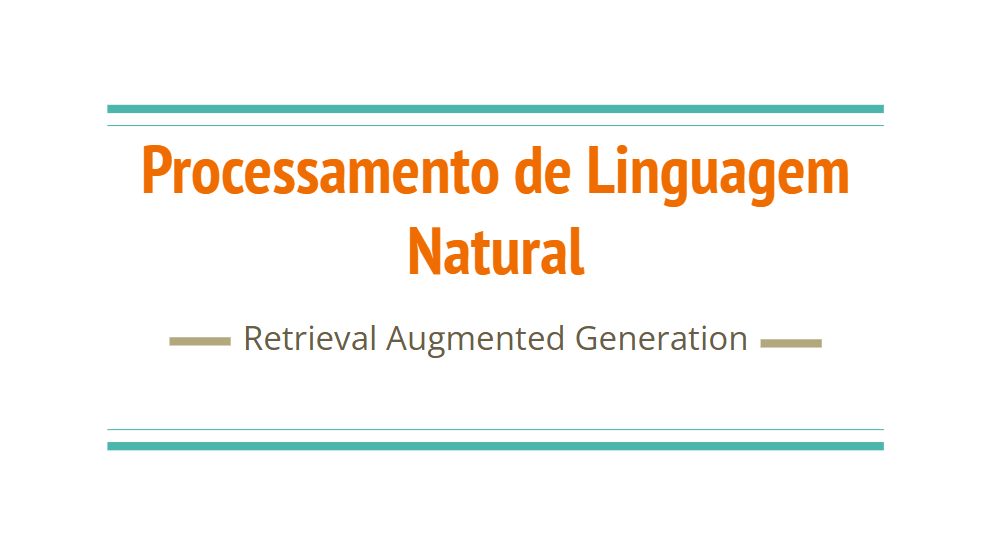

## Introdução

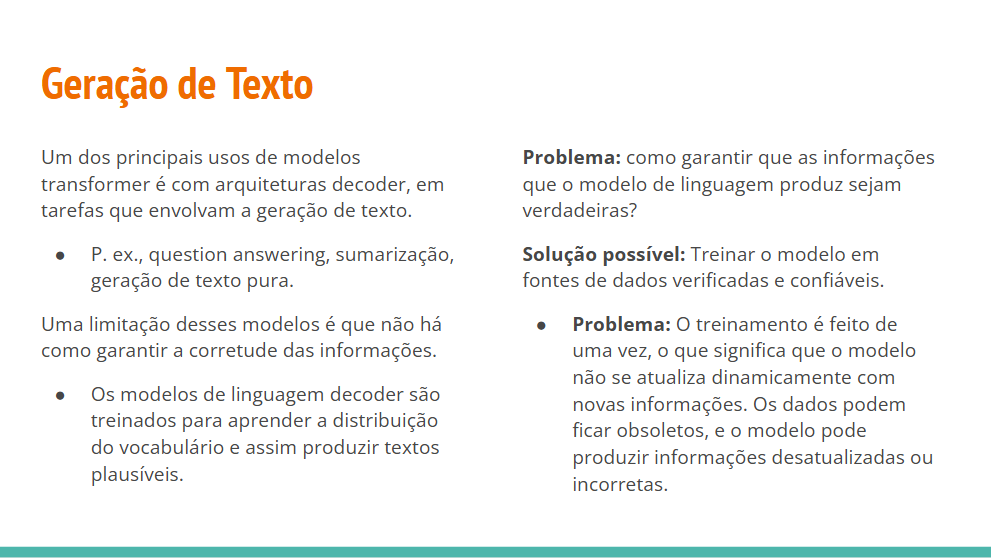

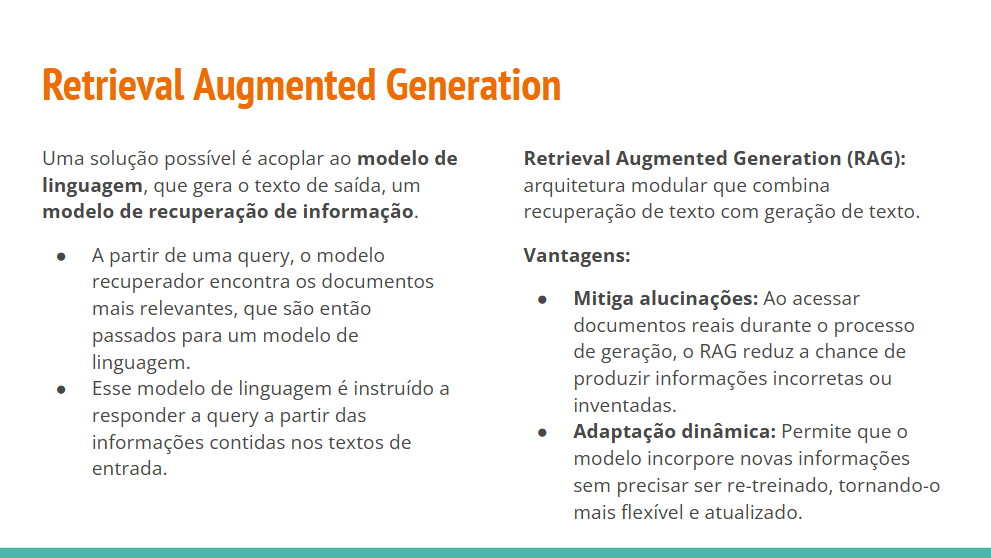

Podemos ilustrar essa dinâmica com um exemplo simples. Imagine que queremos responder à pergunta: "Quais as disciplinas oferecidas no módulo de Inteligência Artificial com Deep Learning, na pós-graduação de IA do Instituto Mauá de Tecnologia?"

Tentaremos responder usando o modelo `Qwen/Qwen2.5-3B-Instruct`.

In [22]:
model_name = "Qwen/Qwen2.5-3B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.97G [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [23]:
pergunta = "Quais as disciplinas oferecidas no módulo de Inteligência Artificial com Deep Learning, na pós-graduação de IA do Instituto Mauá de Tecnologia?"

messages = [
    {"role": "system", "content": "Você é um chatbot útil."},
    {"role": "user", "content": pergunta}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=512
)
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
]

response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

print(response)

Desculpe pela confusão, mas não tenho acesso em tempo real a informações específicas sobre todas as disciplinas oferecidas em cada módulo ou curso atualmente, incluindo o módulo de Inteligência Artificial com Deep Learning da pós-graduação de IA no Instituto Mauá de Tecnologia. 

Para obter essa informação exata e atualizada, recomendo que você:

1. Entre em contato diretamente com o instituto pelo seu site oficial ou redes sociais.
2. Verifique se há uma página específica para os cursos ou módulos em seu site.
3. Procure por material de divulgação acadêmica ou anúncios recentes que possam fornecer essa informação.

As disciplinas frequentemente incluem áreas como:
- Fundamentos de IA
- Redes Neurais Artificiais (RNNs, RBFNs, MLPs)
- Aprendizado de Máquina Supervisionado e Não Supervisionado
- Algoritmos Genéticos
- Projetos de IA
- Técnicas de Visualização de Dados
- Deep Learning
- Redes Neurais Recorrentes (RNNs)
- Redes Neurais Convolutivas (CNNs)
- Processamento de Linguagem Natur

O modelo é incapaz de responder. Isso é esperado: a informação é bastante específica. Pior ainda, pode acontecer de o modelo responder com  convicção, sem que possua de fato a informação (alucinação), enganando o usuário.

O que a arquitetura RAG propõe é usar o LLM apenas para **organizar a resposta** a partir de textos de referência. No nosso caso, essa informação pode ser encontrada [no site da Mauá](https://maua.br/pos-graduacao/atualizacao-120h/inteligencia-artificial-com-deep-learning). Vamos simplesmente copiar o texto da página e salvar em um string.

In [24]:
reference = '''
Inteligência Artificial com Deep-Learning
Objetivo

O objetivo desse curso é apresentar a área inteligência artificial usando redes neurais artificiais "deep-learning". O curso é fundamentado em atividades práticas onde o aluno tem contato real com diversos aspectos da área de redes neurais que está revolucionando o mundo atual. Além das atividades práticas, o curso aborda também os aspectos teóricos, de forma a permitir futuros aprofundamentos. A estrutura do curso, de forma objetiva e bastante enxuta, é voltada para as atuais necessidades do mercado, contemplando os diversos aspectos da área de inteligência artificial com redes neurais. Em apenas um semestre o profissional estará preparado para trabalhar com essa tecnologia que está cada vez mais presente no cotidiano e nas empresas. O corpo docente é formado por profissionais de alto nível acadêmico e com reconhecida experiência profissional na área.

Público-Alvo

Esse curso é dirigido aos profissionais que buscam entender e conhecer as oportunidades criadas por essa nova tecnologia. É ideal para o profissional criativo e prático que busca obter vantagem dos atuais e futuros avanços da inteligência artificial, ou que desejam se atualizar nessa área. É dirigido aos profissionais que atuam ou desejam atuar na área de inteligência artificial (aprendizado de máquina) desenvolvendo novos negócios, novos produtos e novos dispositivos que incorporam essa tecnologia. É também dirigido aos profissionais que desejam incorporar sistemas de inteligência artificial em suas empresas de forma a melhorar e aperfeiçoar o seu desempenho.

Matrícula: R$ 1.780,00
Investimento
Matrícula + 5 parcelas de R$ 2.012,00*
Condições especiais para ex‑alunos, grupos e empresas conveniadas

*Investimento por módulo (120 horas)

*Valores 2026

Descontos
Ex-aluno graduado na Mauá: 10%
Grupos (2 ou mais alunos): 10%
Ex-aluno graduado na Mauá em 2024: 30%
Empresas conveniadas (a consultar)

¹ Descontos não aplicaveis na matrícula;
² Descontos não acumulativos.

São Caetano do Sul
Taxa de Reserva: R$ 300,00
O pagamento poderá ser efetuado por boleto, cartão de débito ou crédito. Na efetivação da matrícula essa Taxa de Reserva será deduzida do valor da matrícula. Em caso de desistência, o valor não será devolvido. Se a turma não se formar, o valor será devolvido integralmente.

Coordenadores

Eduardo Lobo Lustosa Cabral
Doutor em Dinâmica dos Sistemas e Controle pelo Massachusetts Institute of Technology. Mestre em Tecnologia de Reatores Nucleares pelo Instituto de Pesquisas Energéticas e Nucleares. Graduado em Engenharia Mecânica pela USP. Professor da Escola Politécnica da USP e do Instituto Mauá de Tecnologia. Atua nas áreas de inteligência artificial, redes neurais e dinâmica e controle de sistemas.

Vanderlei Cunha Parro
Professor titular do IMT, pesquisador visitante no Observatório de Paris (2004-2006) e bolsista de produtividade do CNPq. Coordenador da participação do IMT nos projetos: Plato (ESA - Agência Espacial Europeia), Telescópio Gigante de Magalhães - EUA e Hires (ESO - Europa), os dois primeiros com financiamento FAPESP.
Disciplinas
Corpo docente


Fundamentos de inteligência artificial
36h
Essa disciplina apresenta os fundamentos de "deep-learning" e o uso das bibliotecas Keras e TensorFlow, que são específicas para o desenvolvimento de redes neurais artificiais. Nessa disciplina os alunos aprendem como criar, treinar e utilizar uma rede neural "deep-learning". A disciplina se baseia em vários estudos de casos para que os alunos aprendam como aplicar na prática redes "deep-learning" em várias áreas do conhecimento. O objetivo principal dessa disciplina é mostrar aos alunos como redes neurais tipo "deep-learning" realmente funcionam e capacitar os alunos a aplicar essas redes em suas próprias aplicações. A utilização do Keras e TensorFlow permite que os alunos aprendam facilmente como formular, criar e implementar problemas de aprendizado de máquina usando redes "deep-learning".

Inteligência artificial aplicada à séries temporais
32h
Essa disciplina apresenta como construir redes neurais recorrentes para processamento de sequências temporais. O objetivo dessa disciplina é ensinar os alunos como funcionam as redes neurais recorrentes e suas variantes. A disciplina se baseia em estudos de casos para que os alunos aprendam como aplicar na prática redes neurais recorrentes "deep-learning" para problemas de análise de séries temporais usando as plataformas de desenvolvimento Keras e TensorFlow.

Inteligência artificial aplicada à visão computacional
32h
Essa disciplina apresenta as redes neurais convolucionais e suas aplicações a imagens e vídeos. O objetivo dessa disciplina é ensinar os alunos como construir redes neurais convolucionais, suas principais variações e como aplicar esse tipo de rede em tarefas de processamento de imagens e vídeos. A disciplina se baseia em estudos de casos para que os alunos aprendam como aplicar na prática redes neurais convolucionais "deep-learning" para detecção e reconhecimento visual.

Processamento Natural de Linguagem (PLN)
32h
O processamento de linguagem natural (PLN) é a subárea da inteligência artificial que estuda a capacidade e as limitações de uma máquina em entender a linguagem dos seres humanos. Esta disciplina aborda normalização de texto, correção ortográfica, “stemização” e “lematização”, idf-tf, extração de contexto, sumarização, “word embedding”, tais como, Word2Vec, FastText, representação de frases com BoW, análise de sentimentos, “chat bots” e utilização de redes neurais para modelagem de linguagem natural, e realizar operações de tradução e sugestão de palavras em contexto, entre outras.
'''

In [25]:
prompt = 'Pergunta: ' + pergunta + 'Texto de referência: ' + reference

messages = [
    {"role": "system", "content": "Você é um chatbot útil. Responda a partir do texto de referência."},
    {"role": "user", "content": prompt}
]

text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=512
)
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
]

response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

print(response)

De acordo com o texto de referência, as disciplinas oferecidas no módulo de Inteligência Artificial com Deep Learning, na pós-graduação de IA do Instituto Mauá de Tecnologia, são:

1. Fundamentos de inteligência artificial
2. Inteligência artificial aplicada à séries temporais
3. Inteligência artificial aplicada à visão computacional
4. Processamento Natural de Linguagem (PLN)

Cada disciplina tem duração de 32 horas.


## RAG

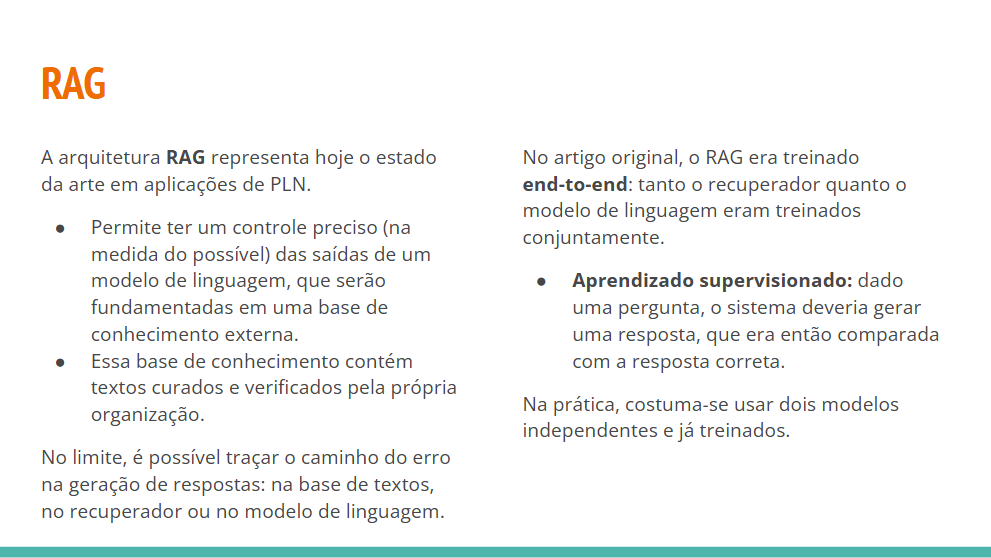

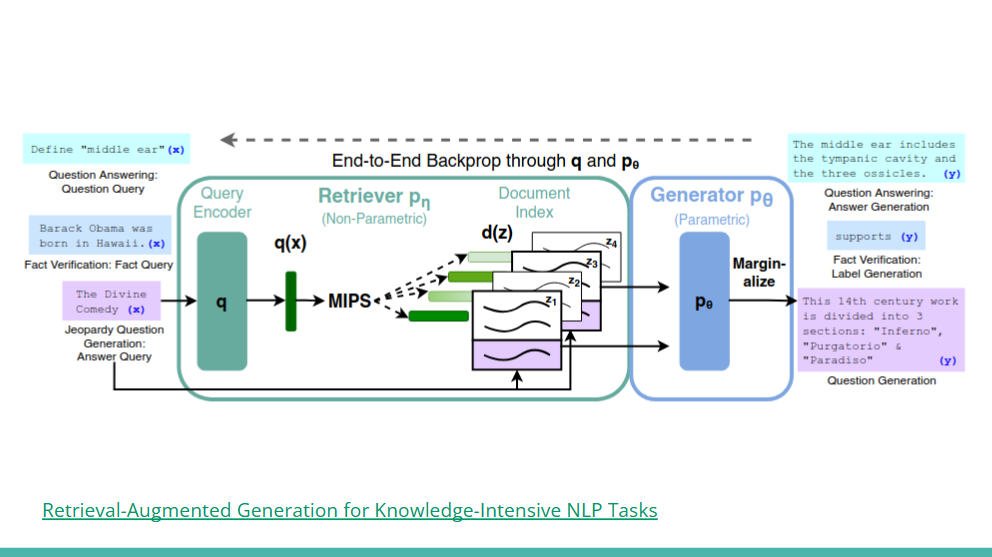

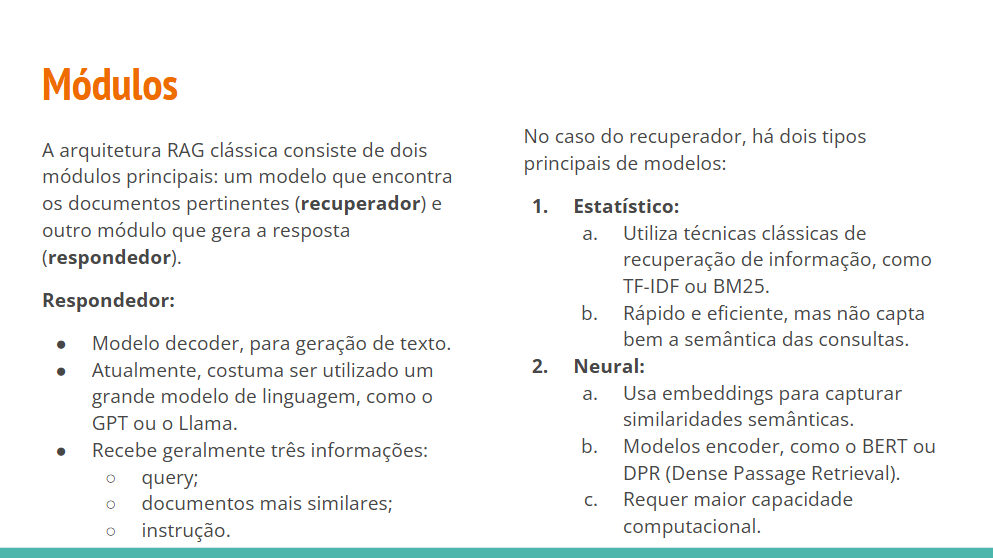

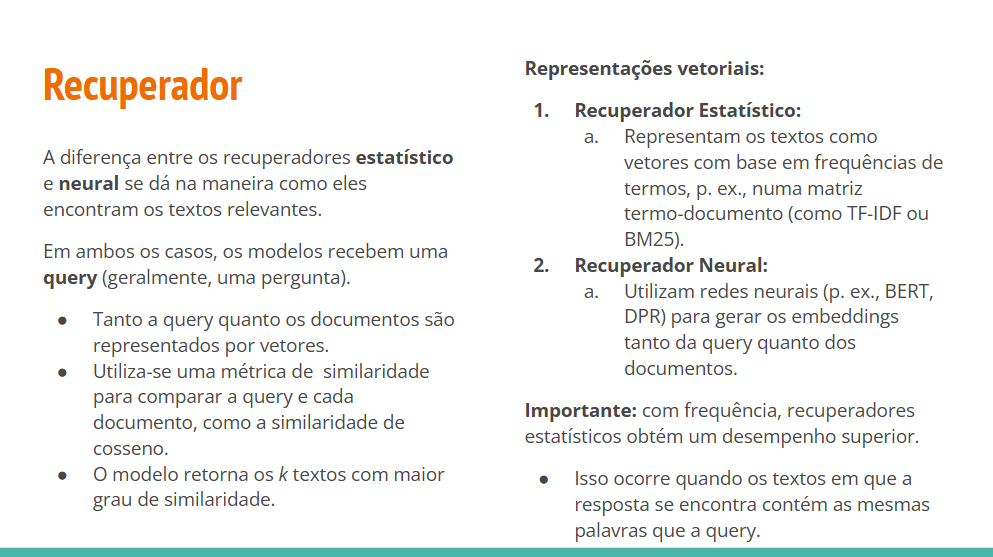

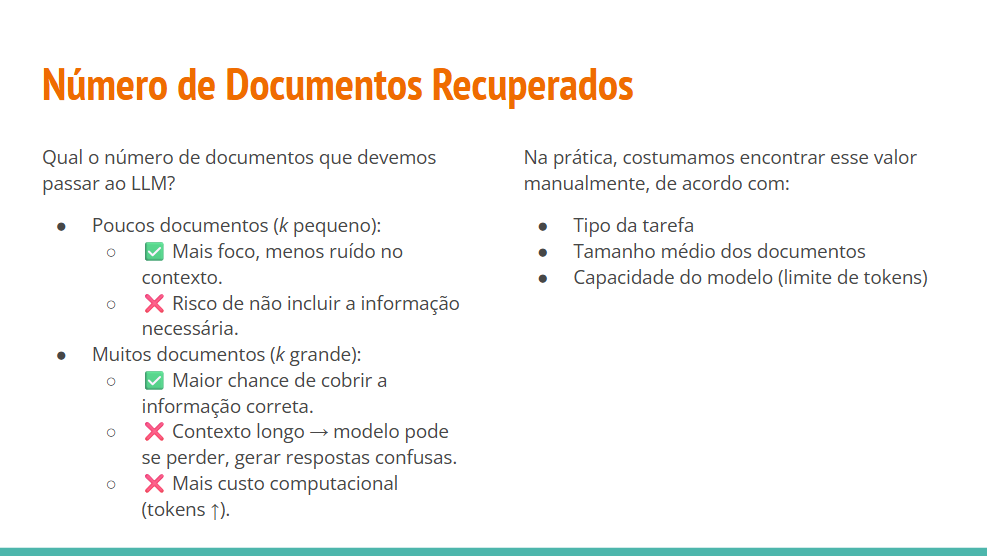

## Aplicação

Nessa aplicação vamos tentar responder às perguntas do **SQuAD**. O SQuAD é um conjunto de dados clássico para **respondimento de questões**. Ele contém uma pergunta, uma resposta e um texto de apoio.

Testaremos três soluções:

1.   Um modelo de linguagem sem recuperador
2.   Um modelo RAG com recuperador estatístico
3.   Um modelo RAG com recuperador neural



### Pré-processamento

Vamos carregar os dados e separar questões, passagens e respostas. No caso das respostas, o SQuAD contém tanto o texto da resposta quanto o token que inicia a resposta: vamos considerar apenas o primeiro.

In [4]:
# Carrega o dataset
ds = load_dataset("rajpurkar/squad")

ds

README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

plain_text/validation-00000-of-00001.par(…):   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 87599
    })
    validation: Dataset({
        features: ['id', 'title', 'context', 'question', 'answers'],
        num_rows: 10570
    })
})

Vamos usar somente as 100 primeiras observações do conjunto validação para acelerar a execução do código.

In [5]:
# Seleciona as questões
questions = ds['validation']['question'][:100]

# Seleciona as passagens
passages = ds['validation']['context'][:100]

# Seleciona as respostas (somente o texto da resposta)
real_answers = [answer['text'][0] for answer in ds['validation']['answers']][:100]

### Métricas

Antes de utilizar os modelos, precisamos definir uma métrica que calcule a semlhança entre as respostas corretas e as respostas geradas pelo modelo. Utilizaremos uma métrica de intersecção de palavras, o **F1-score**.

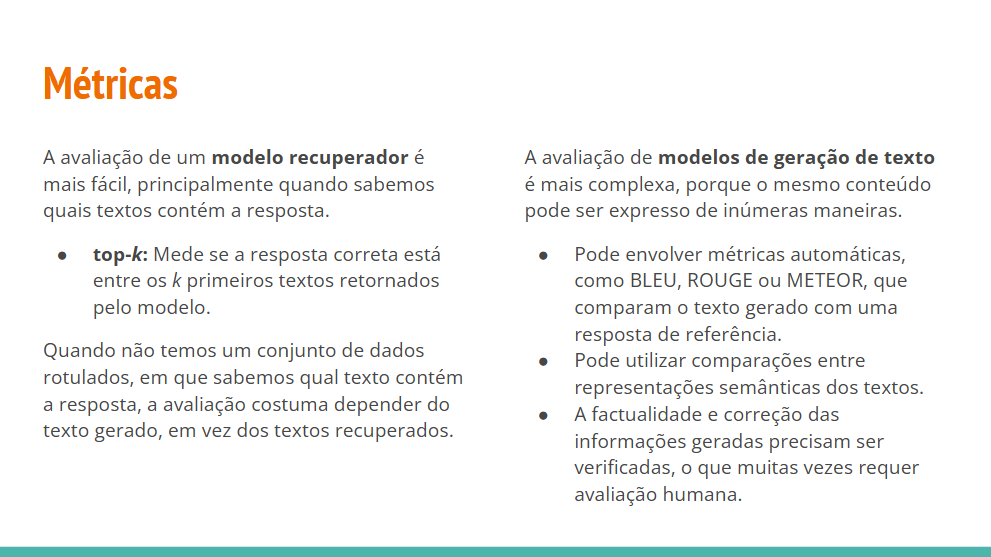

Para o modelo respondedor, utilizaremos o **F1-score**, empregado no SQuAD.

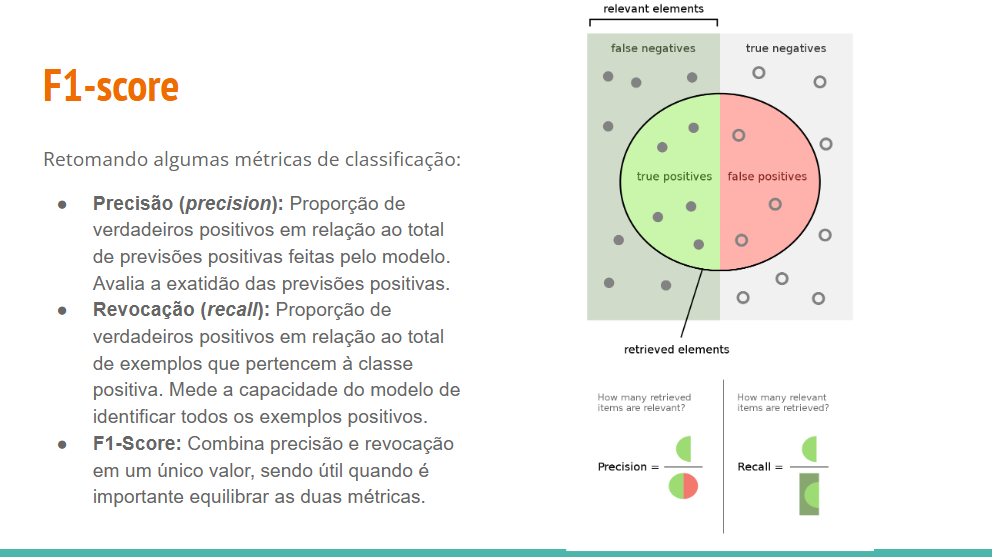

O F1-score, no contexto de perguntas e respostas, mede o quanto as palavras da resposta gerada pelo modelo coincidem com as da resposta correta, equilibrando erros e acertos com base nas palavras em comum. É uma variação do F1-score tradicional, que foca em comparar as palavras presentes tanto na resposta gerada quanto na resposta correta, em vez de simplesmente classificar previsões corretas ou incorretas.

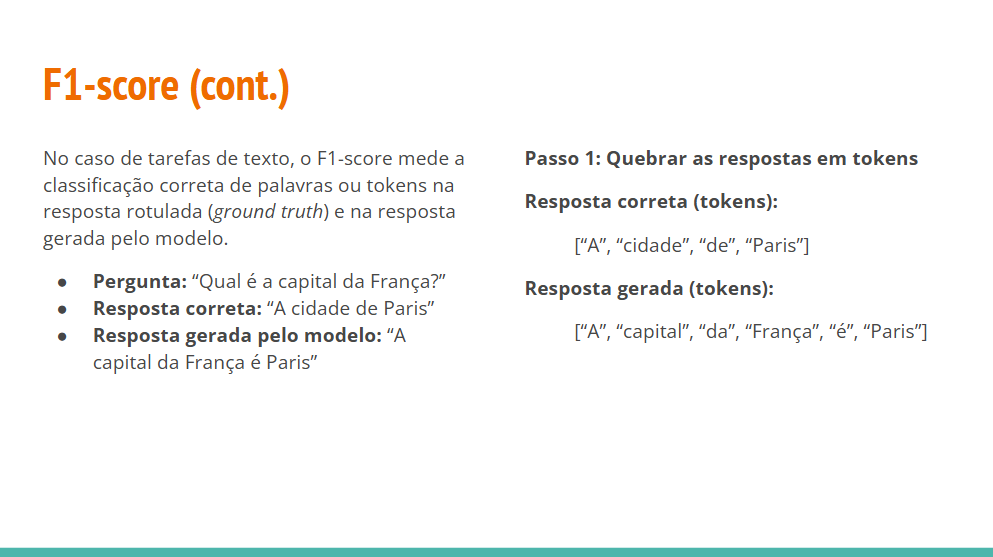

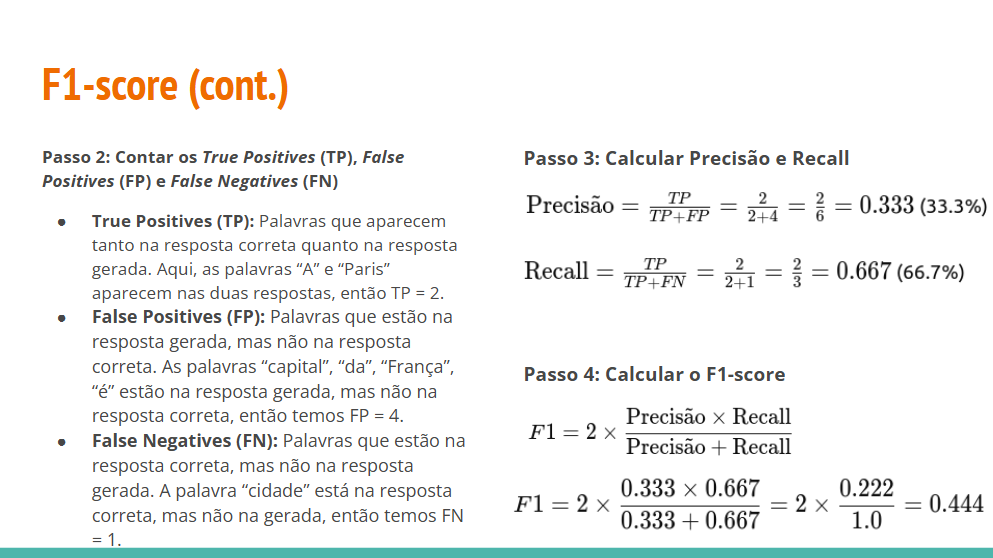

Vamos criar uma função que avalia o F1-score e o exact match. O exact match indica simplesmente se as resposta coincidem perfeitamente ou não.

In [6]:
# Função para normalizar a resposta: removendo pontuação, espaços extras e convertendo para minúsculas
def normalize_answer(s):
    """Lower text and remove punctuation and extra whitespace."""
    def white_space_fix(text):
        return ' '.join(text.split())

    def remove_punc(text):
        exclude = set(string.punctuation)
        return ''.join(ch for ch in text if ch not in exclude)

    def lower(text):
        return text.lower()

    return white_space_fix(remove_punc(lower(s)))


# Função para calcular o F1-score entre uma predição e a resposta correta
def f1_score(prediction, ground_truth):
    prediction_tokens = normalize_answer(prediction).split()
    ground_truth_tokens = normalize_answer(ground_truth).split()
    common = Counter(prediction_tokens) & Counter(ground_truth_tokens)
    num_same = sum(common.values())
    if num_same == 0:
        return 0
    precision = 1.0 * num_same / len(prediction_tokens)
    recall = 1.0 * num_same / len(ground_truth_tokens)
    f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return f1


# Função para calcular a exatidão (Exact Match)
def exact_match_score(prediction, ground_truth):
    return (normalize_answer(prediction) == normalize_answer(ground_truth))


# Função para calcular a métrica máxima para uma predição com múltiplas respostas corretas
def metric_max_over_ground_truths(metric_fn, prediction, ground_truths):
    scores_for_ground_truths = []
    for ground_truth in ground_truths:
        score = metric_fn(prediction, ground_truth)
        scores_for_ground_truths.append(score)
    return max(scores_for_ground_truths)


# Função de avaliação que recebe listas de respostas corretas e predições
def evaluate(gold_answers, predictions):
    f1 = exact_match = total = 0

    for ground_truths, prediction in zip(gold_answers, predictions):
        total += 1
        exact_match += metric_max_over_ground_truths(
            exact_match_score, prediction, [ground_truths])
        f1 += metric_max_over_ground_truths(
            f1_score, prediction, [ground_truths])

    exact_match = 100.0 * exact_match / total
    f1 = 100.0 * f1 / total

    return {'exact_match': exact_match, 'f1': f1}

### Modelo de linguagem

Para facilitar o processo, definimos uma função que gera as respostas a partir de um texto de entrada.

In [36]:
# Função para gerar resposta
def generate_answer(input_text, instruction):

    messages = [
        {"role": "system", "content": instruction},
        {"role": "user", "content": input_text}
    ]

    # Cria o template do chat
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    # Prepara os inputs
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    # Gera tokens
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=512
    )

    # Remove os tokens de entrada para isolar a saída
    generated_ids = [
        output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
    ]

    # Decodifica a resposta
    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return response


Vamos gerar uma resposta para ilustrar o processo. Como parte da instrução, solicitamos que as respostas sejam curtas e diretas, como no SQuAD.

In [26]:
instruction = 'You are a helpful chatbot. Give a short and direct answer.'

sample_question = questions[0]
sample_answer = real_answers[0]

print(f"Pergunta: {sample_question}")
print(f"Resposta gerada: {generate_answer(sample_question, instruction)}")
print(f"Resposta correta: {sample_answer}")

Pergunta: Which NFL team represented the AFC at Super Bowl 50?
Resposta gerada: The Denver Broncos represented the AFC at Super Bowl 50.
Resposta correta: Denver Broncos


Agora, geramos as respostas para as 100 primeiras perguntas.

In [27]:
# Gerar respostas para as perguntas
generated_answers = [generate_answer(q, instruction) for q in questions]

In [28]:
# Calcular a métrica F1
results_lm = evaluate(generated_answers, real_answers)

results = {'simpleLM': results_lm}

print(f"F1 Score LM Simples: {results['simpleLM']}")

F1 Score LM Simples: {'exact_match': 0.0, 'f1': 6.365421722688851}


In [29]:
# Printar as primeiras 5 perguntas, respostas corretas e respostas geradas
for i in range(0, 20, 5):
    print(f"Pergunta {i+1}: {questions[i]}")
    print(f"Resposta correta: {real_answers[i]}")
    print(f"Resposta predita: {generated_answers[i]}")
    print('-' * 80)

Pergunta 1: Which NFL team represented the AFC at Super Bowl 50?
Resposta correta: Denver Broncos
Resposta predita: The NFL team that represented the AFC at Super Bowl 50 was the San Francisco 49ers.
--------------------------------------------------------------------------------
Pergunta 6: What was the theme of Super Bowl 50?
Resposta correta: "golden anniversary"
Resposta predita: The theme of Super Bowl 50 was "Believe."
--------------------------------------------------------------------------------
Pergunta 11: What day was the Super Bowl played on?
Resposta correta: February 7, 2016
Resposta predita: The day of the Super Bowl varies each year; it's typically held on the Sunday preceding the first Monday in February.
--------------------------------------------------------------------------------
Pergunta 16: Super Bowl 50 decided the NFL champion for what season?
Resposta correta: 2015
Resposta predita: Super Bowl 50 decided the NFL champion for the 2015 season.
----------------

### Modelo RAG com TF-IDF

O segundo modelo que iremos testar é um modelo RAG com recuperador estatístico. O primeiro módulo, o recuperador, selecionar o k documentos mais similares à pergunta. Esses resultados são então passados ao modelo de linguagem, que gera uma resposta a partir daí.

Vamos dividir isso em três funções:

*   **retrieve_similar_docs:** Recupera os k documentos mais similares à pergunta utilizando TF-IDF
*   **generate_response:** Gera uma resposta com base nos documentos recuperados (vamos mudar apenas o prompt e as intruções para aproveitar a função anterior)
*   **qa_system:** Sistema de perguntas e respostas modular



In [30]:
# Função para recuperar os documentos mais similares usando TF-IDF
def retrieve_similar_docs_tfidf(question, documents, k=3):
    """
    Recupera os k documentos mais similares à pergunta utilizando TF-IDF.

    :param question: Pergunta de entrada.
    :param documents: Lista de passagens/documentos.
    :param k: Número de documentos a recuperar.
    :return: Lista dos k documentos mais similares e suas similaridades.
    """
    # Vetorização usando TF-IDF
    vectorizer = TfidfVectorizer()
    doc_vectors = vectorizer.fit_transform(documents)

    # Vetorização da pergunta
    question_vector = vectorizer.transform([question])

    # Calcular a similaridade de cosseno
    similarities = cosine_similarity(question_vector, doc_vectors).flatten()

    # Selecionar os índices dos k documentos mais similares
    similar_doc_indices = similarities.argsort()[-k:][::-1]

    # Retornar os documentos mais similares
    return [documents[i] for i in similar_doc_indices], similarities[similar_doc_indices]

In [70]:
# Função principal para fazer a recuperação e gerar a resposta
def qa_system(question, passages, retrieve_method='tfidf', k=3):
    """
    Sistema de perguntas e respostas modular.

    :param question: Pergunta de entrada.
    :param passages: Lista de passagens/documentos.
    :param k: Número de documentos a recuperar.
    :return: Resposta final gerada pelo sistema e documentos recuperados.
    """
    # Passo 1: Recuperar os documentos mais similares usando o método escolhido
    if retrieve_method == 'tfidf':
        retrieved_docs, similarities = retrieve_similar_docs_tfidf(question, passages, k=k)
    elif retrieve_method == 'embeddings':
        retrieved_docs = retrieve_similar_docs_embeddings(question, passages, k=3)
    else:
        raise ValueError("retrieve_method must be 'tfidf' or 'embeddings'")

    # Passo 2: Montar input_text com a pergunta + documentos recuperados
    context = "\n\n".join(retrieved_docs)
    input_text = f"Question: {question}\n\nRetrieved Context:\n{context}"

    # Passo 3: Definir instrução para RAG
    instruction = "You are a helpful chatbot. Answer the user's question based on the retrieved context. Give a short and direct answer."

    # Passo 4: Gerar resposta com base na pergunta + contexto
    response = generate_answer(input_text, instruction)

    # Retornar a resposta gerada e os documentos recuperados
    return response, retrieved_docs

Vejamos a função aplicada a um único exemplo.

In [32]:
# Pergunta de exemplo
sample_question = questions[0]

# Chamar o sistema de QA para a pergunta de exemplo
response, retrieved_docs = qa_system(sample_question, passages, retrieve_method='tfidf', k=3)

# Exibir a pergunta, os documentos recuperados e a resposta gerada
print(f"Pergunta: {sample_question}")
print("Documentos recuperados:")
for i, doc in enumerate(retrieved_docs):
    print(f"Documento {i+1}: {doc}")
print(f"\nResposta gerada: {response}")
print(f"\nResposta correta: {real_answers[0]}")

Pergunta: Which NFL team represented the AFC at Super Bowl 50?
Documentos recuperados:
Documento 1: Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated the National Football Conference (NFC) champion Carolina Panthers 24–10 to earn their third Super Bowl title. The game was played on February 7, 2016, at Levi's Stadium in the San Francisco Bay Area at Santa Clara, California. As this was the 50th Super Bowl, the league emphasized the "golden anniversary" with various gold-themed initiatives, as well as temporarily suspending the tradition of naming each Super Bowl game with Roman numerals (under which the game would have been known as "Super Bowl L"), so that the logo could prominently feature the Arabic numerals 50.
Documento 2: Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for

Aplicando para todo o conjunto de dados.

In [40]:
answers_tfidf = []

# Percorrer todas as perguntas no conjunto de dados
for i, question in enumerate(questions):
    response, retrieved_docs = qa_system(question, passages, retrieve_method='tfidf', k=3)

    # Armazenar as respostas
    answers_tfidf.append(response)

In [41]:
# Calcular a métrica F1
results_tfidf = evaluate(answers_tfidf, real_answers)

results['tfidf'] = results_tfidf

print(f"F1 Score RAG com TF-IDF: {results['tfidf']}")

F1 Score RAG com TF-IDF: {'exact_match': 27.0, 'f1': 42.304915990442304}


In [42]:
# Printar as primeiras 5 perguntas, respostas corretas e respostas geradas
for i in range(0, 20, 5):
    print(f"Pergunta {i+1}: {questions[i]}")
    print(f"Resposta correta: {real_answers[i]}")
    print(f"Resposta predita: {answers_tfidf[i]}")
    print('-' * 80)

Pergunta 1: Which NFL team represented the AFC at Super Bowl 50?
Resposta correta: Denver Broncos
Resposta predita: Denver Broncos
--------------------------------------------------------------------------------
Pergunta 6: What was the theme of Super Bowl 50?
Resposta correta: "golden anniversary"
Resposta predita: The theme of Super Bowl 50 was the "golden anniversary."
--------------------------------------------------------------------------------
Pergunta 11: What day was the Super Bowl played on?
Resposta correta: February 7, 2016
Resposta predita: February 7, 2016
--------------------------------------------------------------------------------
Pergunta 16: Super Bowl 50 decided the NFL champion for what season?
Resposta correta: 2015
Resposta predita: The Super Bowl 50 decided the NFL champion for the 2015 season.
--------------------------------------------------------------------------------


### Modelo RAG com Embeddings

O último modelo que iremos testar é uma versão do RAG que usa representações semânticas. Em vez de procurar os textos por palavras-chaves, como no TF-IDF, vamos utilizar um modelo que produz embeddings tanto para a query quanto para os documentos.

Quando uma pergunta é feita, o modelo produz um embedding para ela, que é então comparado com os embeddings dos documentos. Os documentos mais similares de acordo com essa métrica são retornados.

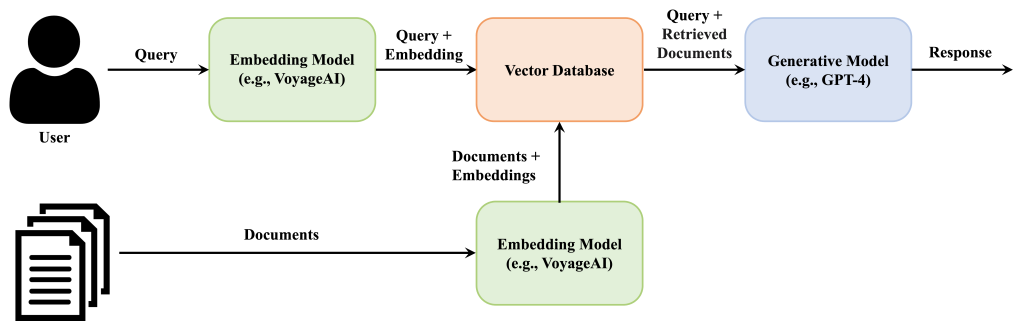

Para gerar os embeddings, vamos utilizar um modelo da família do Sentence-BERT. o Sentence-BERT é um modelo treinado para gerar embeddings de textos, em vez de tokens. Cada documento, assim como a pergunta, será representada por um vetor.

In [51]:
# Definir o modelo de embedding
embedding_model_name = 'paraphrase-MiniLM-L6-v2'
embedding_model = SentenceTransformer(embedding_model_name)

Vamos gerar os gera embeddings de todos os documentos uma única vez.


In [52]:
# gera embeddings dos docs
doc_embeddings = embedding_model.encode(passages)

In [71]:
# Função para recuperar os documentos mais similares à pergunta usando Sentence-BERT
def retrieve_similar_docs_embeddings(question, documents, k=3):

    # Gerar o embedding da pergunta
    question_embedding = embedding_model.encode([question])

    # Calcular a similaridade de cosseno entre a pergunta e os documentos
    similarities = cosine_similarity(question_embedding, doc_embeddings).flatten()

    # Selecionar os índices dos k documentos mais similares
    similar_doc_indices = similarities.argsort()[-k:][::-1]

    # Retornar os documentos mais similares e suas similaridades
    return [documents[i] for i in similar_doc_indices]

Vejamos a função aplicada a um único exemplo.


In [76]:
# Pergunta de exemplo
sample_question = questions[0]

# Chamar o sistema de QA para a pergunta de exemplo
response, retrieved_docs = qa_system(sample_question, passages, retrieve_method='embeddings', k=3)

# Exibir a pergunta, os documentos recuperados e a resposta gerada
print(f"Pergunta: {sample_question}")
print("\nDocumentos recuperados:")
for i, doc in enumerate(retrieved_docs, start=1):
    print(f"Documento {i}: {doc}")

print(f"\nResposta gerada: {response}")
print(f"\nResposta correta: {real_answers[0]}")

Pergunta: Which NFL team represented the AFC at Super Bowl 50?

Documentos recuperados:
Documento 1: Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated the National Football Conference (NFC) champion Carolina Panthers 24–10 to earn their third Super Bowl title. The game was played on February 7, 2016, at Levi's Stadium in the San Francisco Bay Area at Santa Clara, California. As this was the 50th Super Bowl, the league emphasized the "golden anniversary" with various gold-themed initiatives, as well as temporarily suspending the tradition of naming each Super Bowl game with Roman numerals (under which the game would have been known as "Super Bowl L"), so that the logo could prominently feature the Arabic numerals 50.
Documento 2: Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) fo

Aplicando para todo o conjunto de dados.

In [77]:
answers_embedding = []

# Percorrer todas as perguntas no conjunto de dados
for i, question in enumerate(questions):
    response, retrieved_docs = qa_system(question, passages, retrieve_method='embeddings', k=3)

    # Armazenar as respostas
    answers_embedding.append(response)

In [78]:
# Calcular a métrica F1
results_embedding = evaluate(answers_embedding, real_answers)

results['results_embedding'] = results_embedding

print(f"F1 Score RAG com embeddings: {results['results_embedding']}")

F1 Score RAG com embeddings: {'exact_match': 32.0, 'f1': 50.133866013213826}


In [79]:
# Printar as primeiras 5 perguntas, respostas corretas e respostas geradas
for i in range(0, 20, 5):
    print(f"Pergunta {i+1}: {questions[i]}")
    print(f"Resposta correta: {real_answers[i]}")
    print(f"Resposta predita: {answers_embedding[i]}")
    print('-' * 80)

Pergunta 1: Which NFL team represented the AFC at Super Bowl 50?
Resposta correta: Denver Broncos
Resposta predita: Denver Broncos
--------------------------------------------------------------------------------
Pergunta 6: What was the theme of Super Bowl 50?
Resposta correta: "golden anniversary"
Resposta predita: The theme of Super Bowl 50 was the "golden anniversary."
--------------------------------------------------------------------------------
Pergunta 11: What day was the Super Bowl played on?
Resposta correta: February 7, 2016
Resposta predita: February 7, 2016
--------------------------------------------------------------------------------
Pergunta 16: Super Bowl 50 decided the NFL champion for what season?
Resposta correta: 2015
Resposta predita: The Super Bowl 50 decided the NFL champion for the 2015 season.
--------------------------------------------------------------------------------


### Resultados

Por último, vamos plotar os resultados para comparar os resultados.

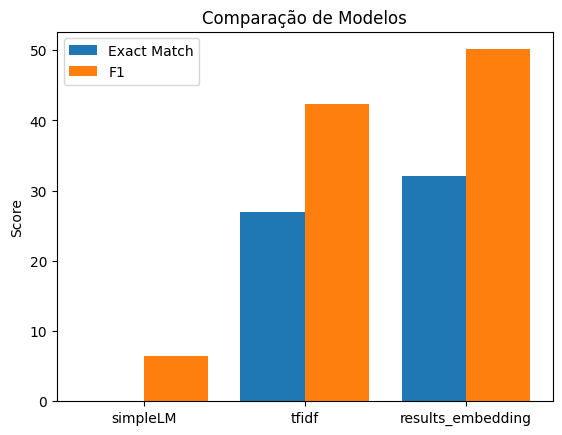

In [85]:
# Extrair dados
models = list(results.keys())
exact_match = [results[m]['exact_match'] for m in models]
f1_scores = [results[m]['f1'] for m in models]

# Criar gráfico
x = range(len(models))
plt.bar([i - 0.2 for i in x], exact_match, width=0.4, label='Exact Match')
plt.bar([i + 0.2 for i in x], f1_scores, width=0.4, label='F1')

# Customização
plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Comparação de Modelos")
plt.legend()
plt.show()

## Ferramentas

Nessa atividade, construímos os componentes do modelo RAG separadamente. Na prática, existem ferramentas que facilitam tornam esse processo mais fácil.

Uma delas é do próprio HuggingFace, onde podemos encontrar os modelos e as APIs para construir os componentes do RAG: https://huggingface.co/docs/transformers/model_doc/rag

Existe também uma biblioteca muito conhecida chamada [LangChain]( https://python.langchain.com/docs/introduction/). O LangChain é um framework que permite construir aplicações com LLMs, como Chatbots e agentes.

Outra possibilidade é o [OLlama](https://ollama.com/), que permite baixar e executar localmente LLMs.

### Visão Geral de um modelo RAG

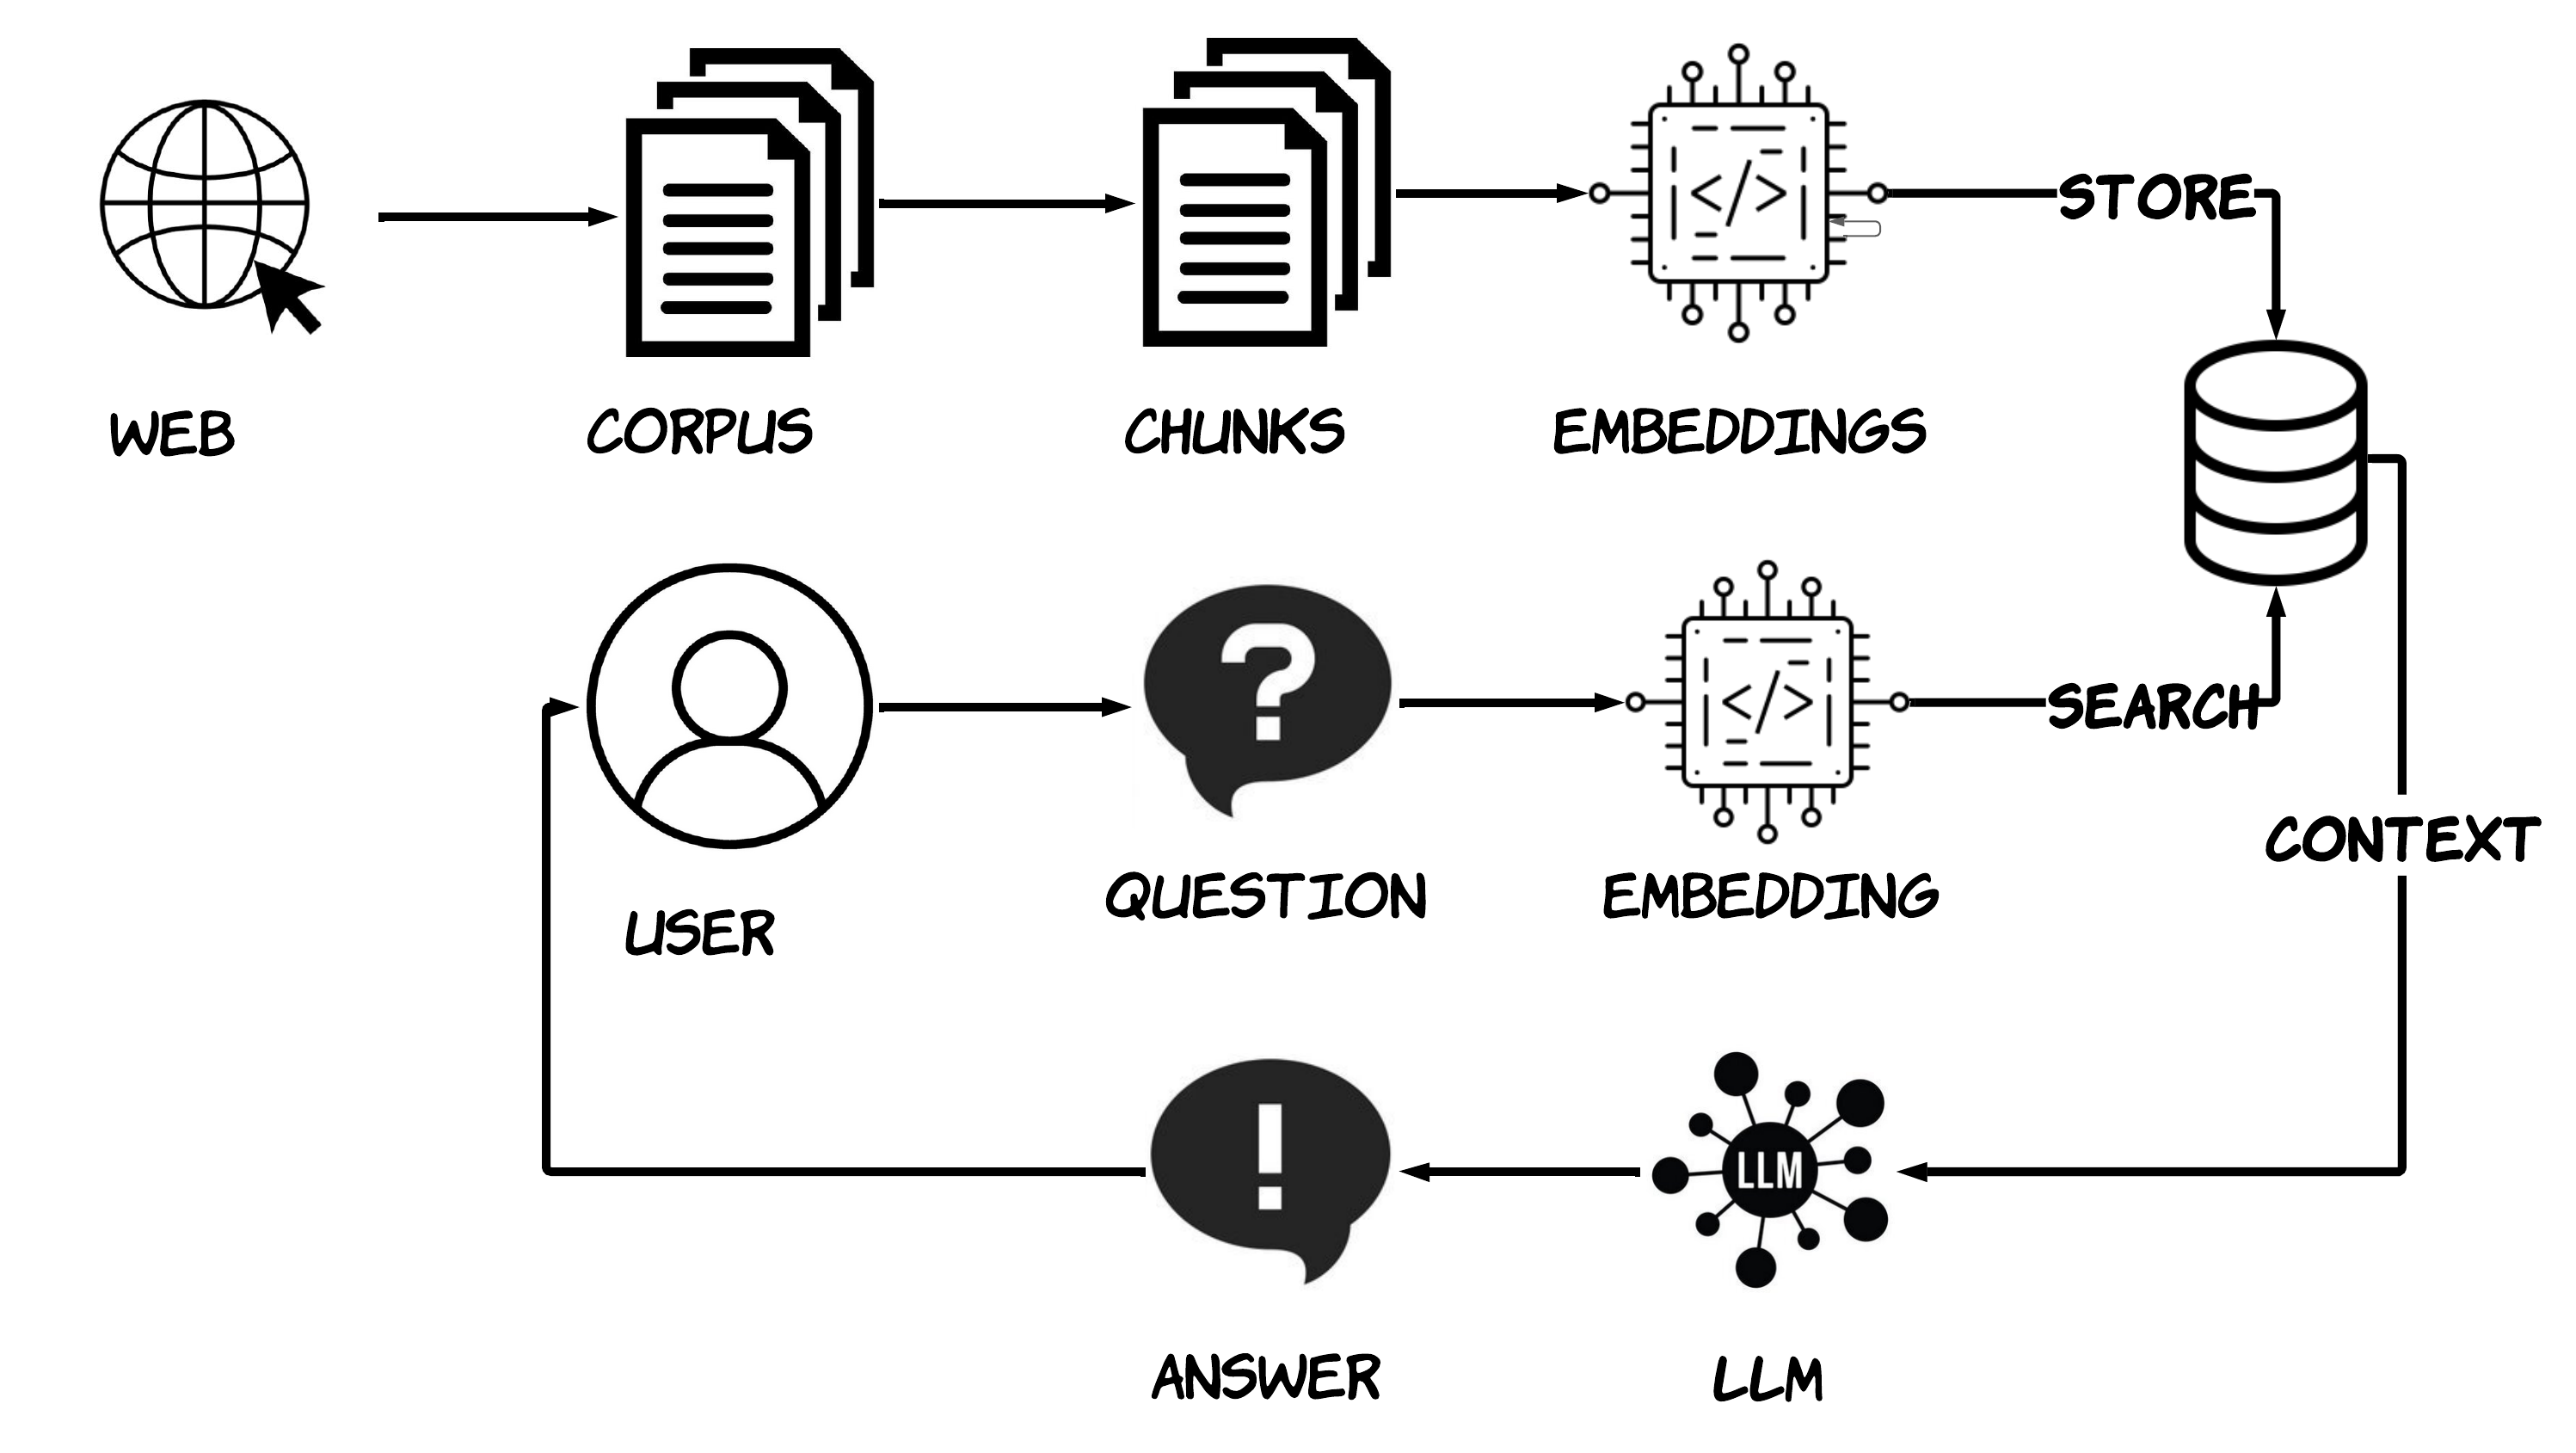

## Aplicações

Nesta atividade, vamos construir um modelo RAG para responder perguntas sobre a costa brasileira. O conjunto de dados encontra-se no seguinte repositório: https://github.com/C4AI/Pira.

In [2]:
!pip install langchain faiss-cpu langchain-community langchain-core

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 5.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


In [3]:
from langchain.chains import LLMChain
from langchain_community.llms import HuggingFacePipeline
from langchain.prompts import PromptTemplate
from langchain.chains import RetrievalQA, StuffDocumentsChain
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from transformers import AutoModelForCausalLM, AutoTokenizer, LlamaConfig, pipeline
import pandas as pd
import random

### Importar o dataset

In [4]:
url = "https://raw.githubusercontent.com/C4AI/Pira/main/Data/train.csv"
df = pd.read_csv(url)

df = df[['abstract', 'question_en_origin', 'answer_en_origin']]

df

,abstract,question_en_origin,answer_en_origin
0,Turbulent air-sea heat fluxes were computed fr...,What method can be used to estimate air–sea se...,The turbulent covariance method.
1,Human health can be affected by many aspects o...,Why is mercury considered one of the ten most ...,"Because in humans, exposure can be harmful to ..."
2,Marine hydrates (mainly methane hydrates) exis...,What are the biological benefits of marine hyd...,Marine hydrates with seeping gas are high biod...
3,"In 1939, the Lobito oil field, Brazil's first,...",What is the most productive oil province in Br...,The Campos basin
4,Cultural services and other social benefits of...,What is the importance of the cultural practic...,They are essential to the maintenance and crea...
...,...,...,...
1801,Distribution of ocean benefits and disbenefits...,What is the proportion of women among the seaf...,Worldwide aproximatly two per cent of the seaf...
1802,"High concentrations of total arsenic (As), eve...",Increased arsenic levels on the coastal enviro...,"Brazil, Chile, Colombia and Argentina."
1803,"In any new drilling project, the main objectiv...",What are the characteristics of the constructi...,"Use of sophisticated equipments, complex opera..."
1804,"In South America, Brazil is the country with t...",What happened with the mangrove of the Coreaú ...,There was an increase of 3% (7.17 km²) in 2013...


### Vector Store

In [5]:
# Carregar os abstracts
abstracts = df['abstract'].tolist()

# Criar embeddings usando o modelo "all-MiniLM-L6-v2"
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Criar um banco de vetores com os embeddings dos abstracts
vector_store = FAISS.from_texts(abstracts, embeddings)

/tmp/ipython-input-4034271675.py:5: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the :class:`~langchain-huggingface package and should be used instead. To use it run `pip install -U :class:`~langchain-huggingface` and import as `from :class:`~langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or 

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [6]:
### Usando chunks de texto
# Função para dividir textos em chunks menores
def chunk_text(text, chunk_size=200, overlap=50):
    words = text.split()
    chunks = []
    for i in range(0, len(words), chunk_size - overlap):
        chunk = ' '.join(words[i:i + chunk_size])
        chunks.append(chunk)
    return chunks

# Dividir em chunks
all_chunks = []
chunk_to_doc_map = []  # Para mapear chunks aos documentos originais

for i, abstract in enumerate(abstracts):
    chunks = chunk_text(abstract)
    all_chunks.extend(chunks)
    chunk_to_doc_map.extend([i] * len(chunks))  # Mapeia cada chunk para o índice do documento original

# Criar embeddings usando o modelo "all-MiniLM-L6-v2"
embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")

# Criar um banco de vetores com os embeddings dos chunks
vector_store = FAISS.from_texts(all_chunks, embeddings)

In [26]:
# Ver o tamanho do vector_store
vector_store_size = vector_store.index.ntotal
print(f"Tamanho do vector_store: {vector_store_size}")

Tamanho do vector_store: 3933


### Pipeline

In [27]:
# Criar pipeline para o LLM
llm_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=150,  # Número de tokens a serem gerados
    temperature=0.6,
    top_p=0.9
)

# Integrar o pipeline com LangChain
llm = HuggingFacePipeline(pipeline=llm_pipeline)

Device set to use cuda:0


### Prompt

In [28]:
# Criar um template de prompt para QA
prompt_template = """
Answer the user's question based on the retrieved context. Give a short and direct answer.

Context: {context}

Question: {question}

Answer:"""

prompt = PromptTemplate(
    input_variables=["context", "question"],
    template=prompt_template
)

### RAG

In [29]:
# Criar a cadeia de combinação de documentos (StuffDocumentsChain) e especificar 'document_variable_name'
stuff_chain = StuffDocumentsChain(
    llm_chain=LLMChain(llm=llm, prompt=prompt),
    document_variable_name="context"
)

# Configurar o QA com LangChain
n_documents = 3  # Número de documentos a serem considerados

qa = RetrievalQA(
    combine_documents_chain=stuff_chain,
    retriever=vector_store.as_retriever(search_kwargs={"k": n_documents})  # Retornar n documentos
)

### Responder Questões

In [30]:
# Função para responder perguntas
def answer_question(question, index):
    # Obter a resposta gerada pelo modelo
    response = qa.run(question)

    # Extrair apenas a parte após "Answer:" e antes da primeira nova linha
    if "Answer:" in response:
        response = response.split("Answer:")[1].split("\n")[0].strip()

    # Obter a resposta correta do dataset
    correct_answer = df['answer_en_origin'][index]

    return response, correct_answer

In [33]:
# Gerar número aleatório
random_index = random.randint(0, len(df) - 1)
random_index

1174

In [34]:
# Testar com uma das perguntas do dataset
sample_question = df['question_en_origin'][random_index]
sample_context = df['abstract'][random_index]
generated_answer, real_answer = answer_question(sample_question, random_index)
print(f"Context: {sample_context}")
print(f"Question: {sample_question}")
print(f"Generated Answer: {generated_answer}")
print(f"Real Answer: {real_answer}")

Context: Global aquaculture production in 2017 (animals and plants) was recorded as 111.9 million tons, with an estimated firstsale value of $249.6 billion. Since 2000, world aquaculture has ceased to enjoy the high annual growth rates of the 1980s and 1990s (11.3 and 10.0 per cent, respectively). Nevertheless, it continues to grow at a faster rate than other major food production sectors. Annual growth declined to a moderate 5.8 per cent during the period from 2000 to 2016, although double-digit growth still occurred in a small number of countries, in particular in Africa, from 2006 to 2010. Fish produced by this rapidly growing sector is high in protein and contains essential micronutrients, sometimes essential fatty acids, which cannot easily be substituted by other food commodities. The United Nations predicts that the global population will reach 8.5 billion in 2030. This will inevitably increase the pressure on food sectors to increase production and reduce losses and waste. Prod

## Agentes

A área que mais tem crescido ultimamente é a construção de **agentes**.

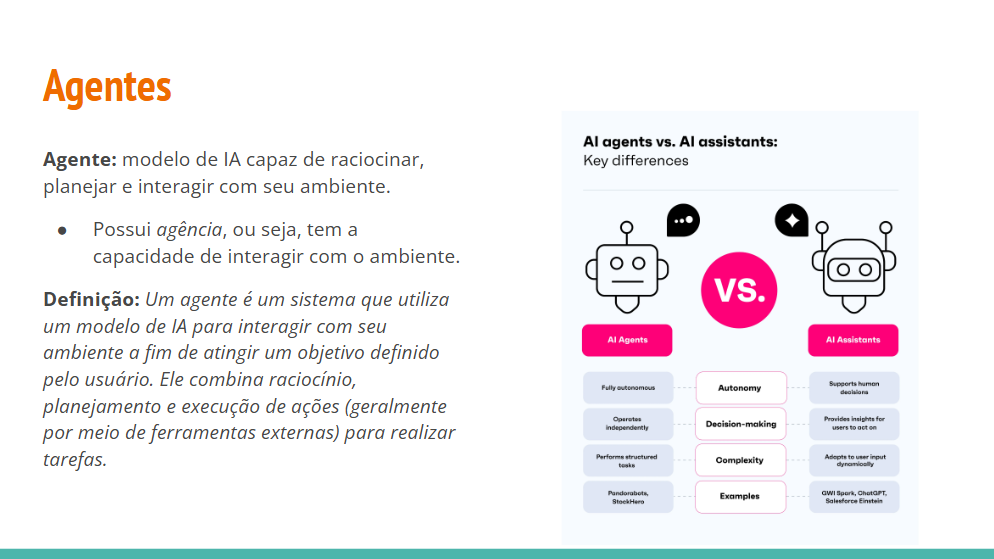

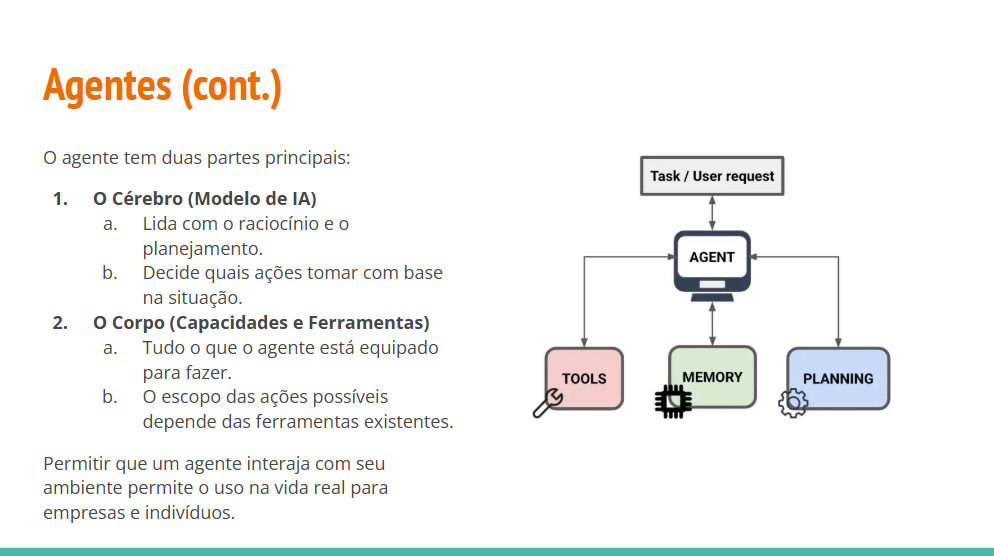

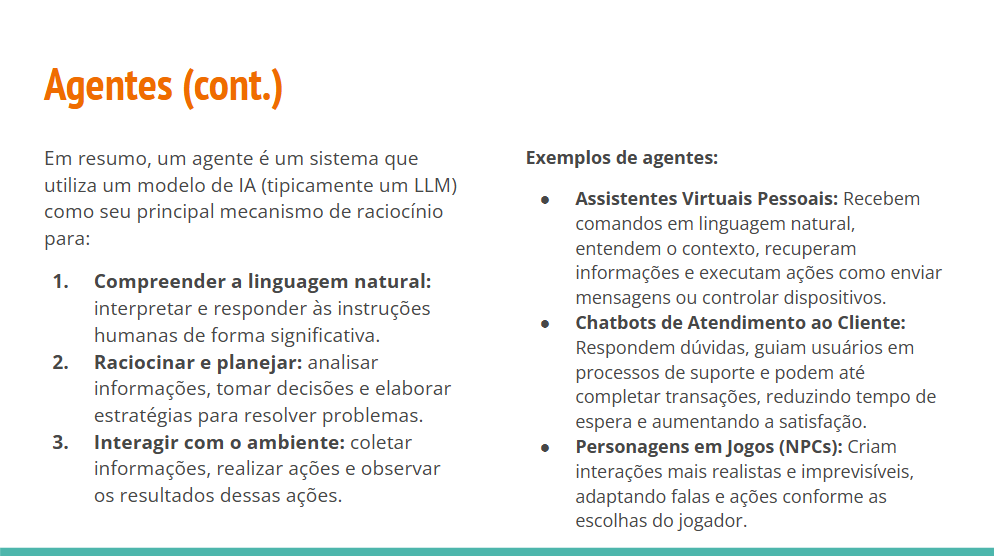

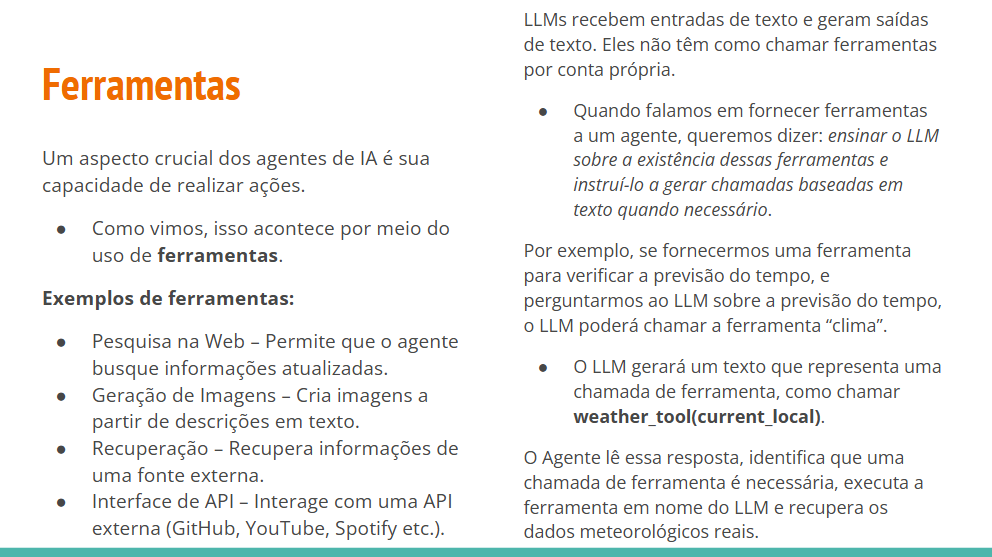

Vejamos duas aplicações simples.

### Calculadora

Queremos realizar uma conta a partir de uma entrada do usuário. O LLM retorna o código para realizar a conta, que então é executada pelo python.

In [40]:
def math_agent(question):
    instruction = (
        "Você é um agente que resolve contas matemáticas escrevendo um código Python. "
        "Retorne apenas o código Python que deve ser executado. "
        "O resultado deve estar armazenado em uma variável chamada result."
    )

    code = generate_answer(question, instruction)

    # Executar o código gerado com segurança
    local_vars = {}
    try:
        exec(code, {}, local_vars)
        result = local_vars.get("result", None)
    except Exception as e:
        result = f"Erro ao executar o código: {e}"

    return code, result

In [41]:
# Exemplo
question = "Qual é a soma de 23047234 * 345623546?"
code, result = math_agent(question)

print("=== Código gerado ===")
print(code)
print("=== Resultado ===")
print(result)

=== Código gerado ===
result = 23047234 * 345623546
=== Resultado ===
7965666740571764


### Previsão do tempo

O LLM decide se deve consultar o clima. Se sim, recorre a uma API que obtém a previsão em tempo real.

In [63]:
import requests

def fetch_temp_open_meteo(lat, lon):
    """
    Consulta Open-Meteo para obter temperatura atual (2m) no local.
    Retorna temperatura em °C ou lança erro.
    """
    # Parâmetros exemplo para current weather
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": lat,
        "longitude": lon,
        "current_weather": True,
        # Você pode pedir variáveis extras, ex: "hourly": "temperature_2m"
    }
    resp = requests.get(url, params=params, timeout=10)
    data = resp.json()
    if "current_weather" not in data:
        raise RuntimeError(f"Resposta inesperada da Open-Meteo: {data}")
    current = data["current_weather"]
    # Em muitos casos, o atributo se chama "temperature" ou "temperature_2m"
    if "temperature" in current:
        return current["temperature"]
    elif "temperature_2m" in current:
        return current["temperature_2m"]
    else:
        raise RuntimeError(f"Não achei campo de temperatura: {current}")

def weather_agent_open_meteo(question, lat=None, lon=None):
    """
    Agente de clima: decide se deve consultar Open-Meteo ou responder normalmente.
    Você pode passar lat/lon de exemplo (ex: para São Paulo).
    """
    instruction = (
        "Você é um agente que decide se a pergunta pede consultar o clima atual. "
        "Se pedir, responda somente a palavra: CALL_WEATHER"
    )
    decision = generate_answer(question, instruction).strip()
    if "CALL_WEATHER" in decision:
        if lat is None or lon is None:
            # Aqui você poderia usar geocodificação ou retornar erro
            return "Não sei as coordenadas para consultar o clima."
        try:
            temp = fetch_temp_open_meteo(lat, lon)
            return f"A temperatura no local (lat={lat}, lon={lon}) agora é {temp}°C"
        except Exception as e:
            return f"Erro ao obter clima: {e}"
    else:
        return decision

In [66]:
# Ex: São Paulo — coordenadas aproximadas
lat_sp = -23.5505
lon_sp = -46.6333

print(weather_agent_open_meteo("Qual é o tempo em São Paulo agora?", lat_sp, lon_sp))

A temperatura no local (lat=-23.5505, lon=-46.6333) agora é 24.6°C
